/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

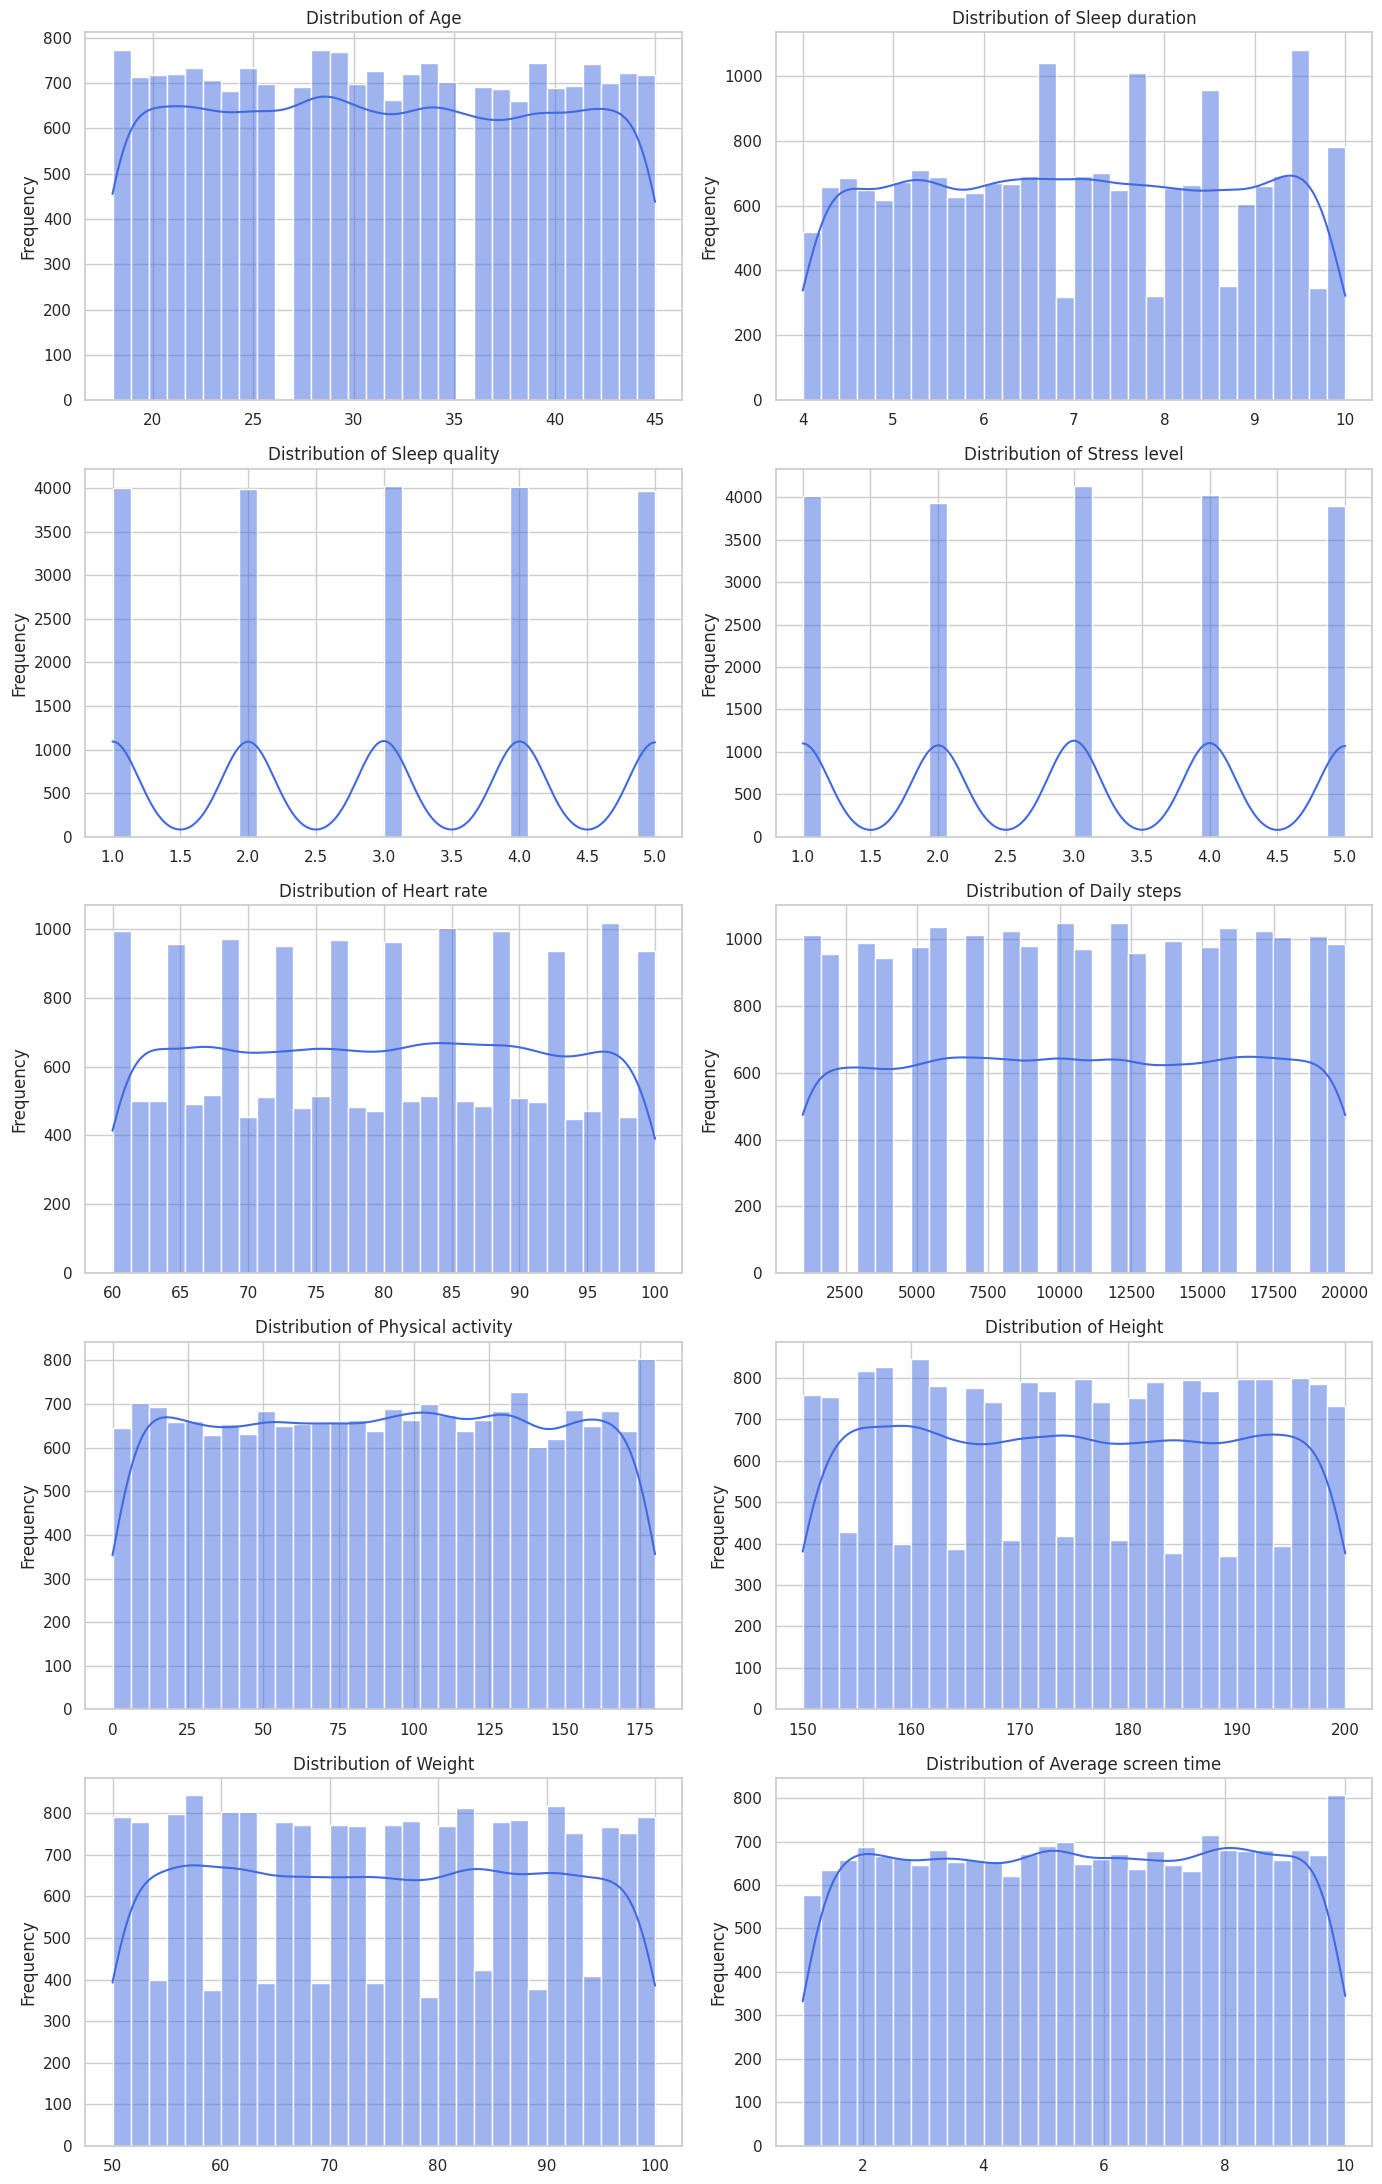

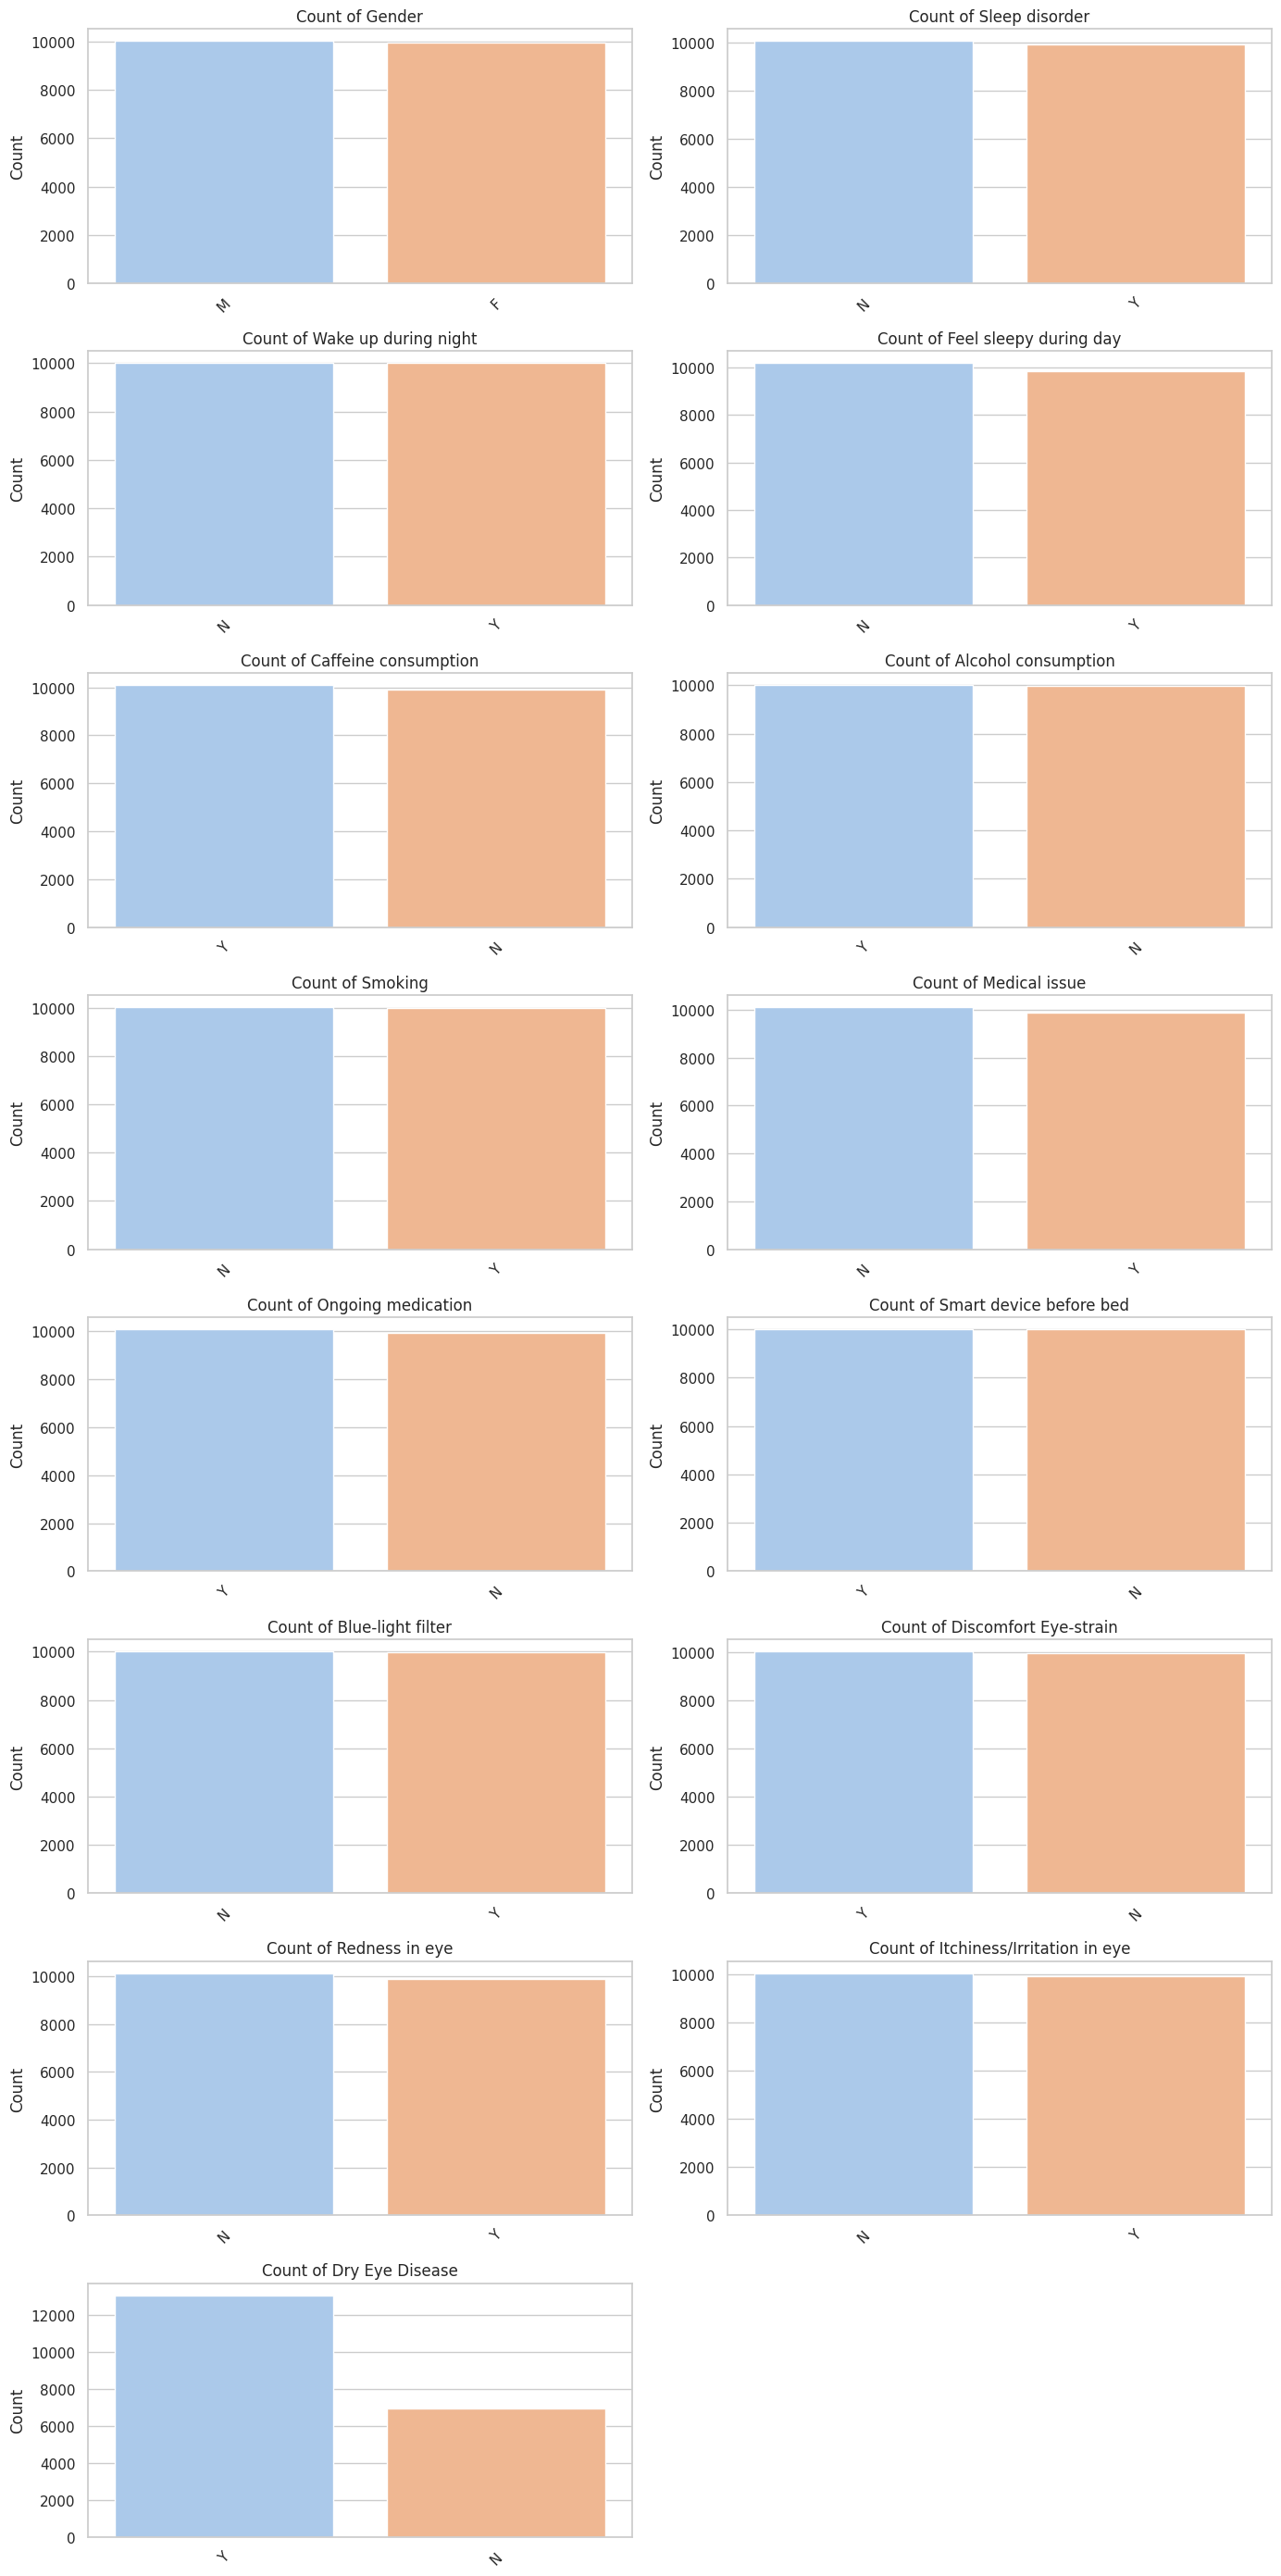

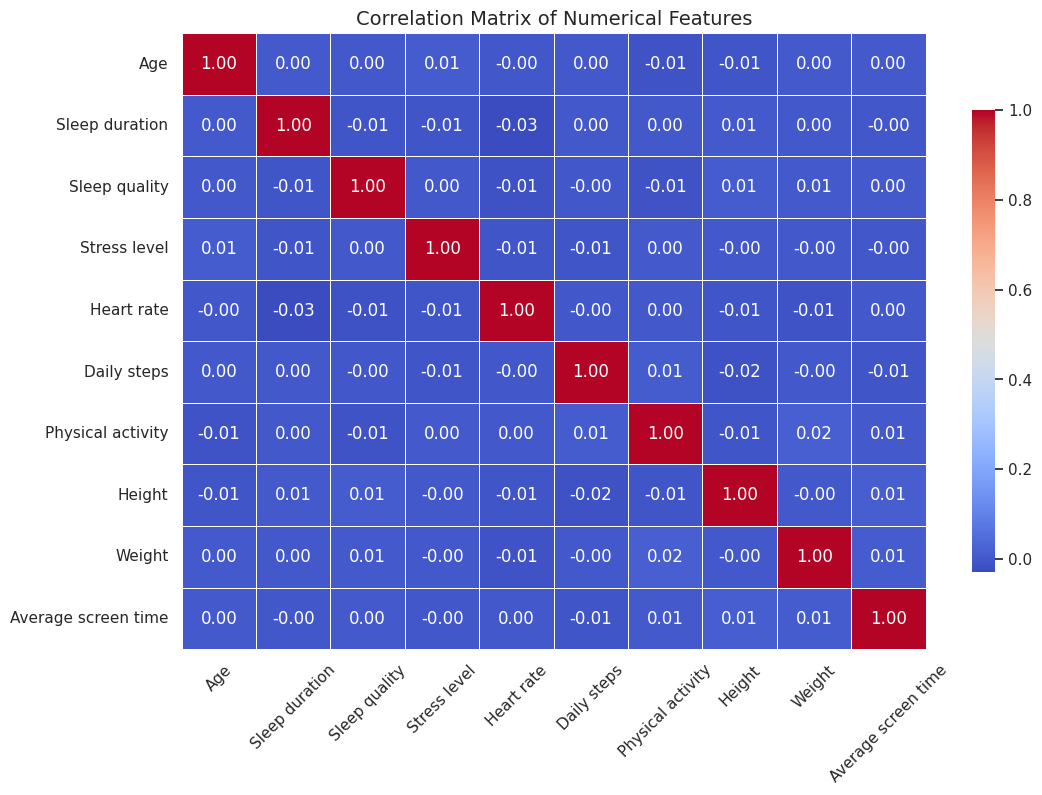

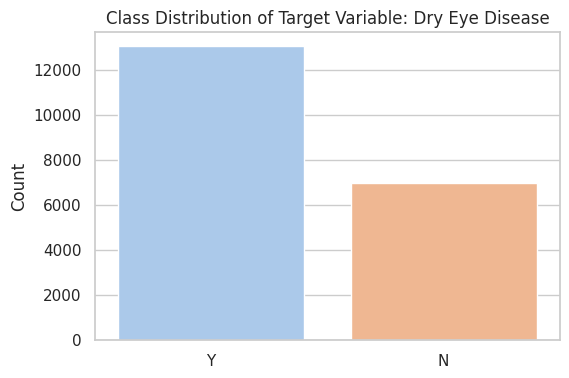

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
file_path = "/kaggle/input/dry-eye-disease/Dry_Eye_Dataset.csv"
df = pd.read_csv(file_path)

# Set style
sns.set(style="whitegrid")

# Plot distributions for numerical features
numerical_features = ['Age', 'Sleep duration', 'Sleep quality', 'Stress level', 'Heart rate', 'Daily steps',
                      'Physical activity', 'Height', 'Weight', 'Average screen time']

fig, axes = plt.subplots(nrows=(len(numerical_features) + 1) // 2, ncols=2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="royalblue")
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Remove unused subplots if features count is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Countplot for categorical features
categorical_features = ['Gender', 'Sleep disorder', 'Wake up during night', 'Feel sleepy during day',
                        'Caffeine consumption', 'Alcohol consumption', 'Smoking', 'Medical issue',
                        'Ongoing medication', 'Smart device before bed', 'Blue-light filter',
                        'Discomfort Eye-strain', 'Redness in eye', 'Itchiness/Irritation in eye', 'Dry Eye Disease']

fig, axes = plt.subplots(nrows=(len(categorical_features) + 1) // 2, ncols=2, figsize=(14, 28))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=df[col], ax=axes[i], order=df[col].value_counts().index, palette="pastel")
    axes[i].set_title(f"Count of {col}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)  # Rotate labels for better readability

# Remove unused subplots if features count is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df[numerical_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.75})
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Target class balance
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Dry Eye Disease'], order=df['Dry Eye Disease'].value_counts().index, palette="pastel")
plt.title("Class Distribution of Target Variable: Dry Eye Disease", fontsize=12)
plt.xlabel("")
plt.ylabel("Count")
plt.show()


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
file_path = "/kaggle/input/dry-eye-disease/Dry_Eye_Dataset.csv"
df = pd.read_csv(file_path)

# Encode categorical features
categorical_features = ['Gender', 'Sleep disorder', 'Wake up during night', 'Feel sleepy during day',
                        'Caffeine consumption', 'Alcohol consumption', 'Smoking', 'Medical issue',
                        'Ongoing medication', 'Smart device before bed', 'Blue-light filter',
                        'Discomfort Eye-strain', 'Redness in eye', 'Itchiness/Irritation in eye', 'Dry Eye Disease']

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Convert Blood Pressure into two separate numerical columns
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood pressure'].str.split('/', expand=True).astype(float)
df.drop(columns=['Blood pressure'], inplace=True)

# Define numerical features
numerical_features = ['Age', 'Sleep duration', 'Sleep quality', 'Stress level', 'Heart rate', 'Daily steps',
                      'Physical activity', 'Height', 'Weight', 'Average screen time', 'Systolic_BP', 'Diastolic_BP']

# Standardize numerical features
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Split data into features and target
X = df.drop(columns=['Dry Eye Disease'])
y = df['Dry Eye Disease']


In [6]:
df.head()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Heart rate,Daily steps,Physical activity,Height,Weight,...,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease,Systolic_BP,Diastolic_BP
0,0,-0.915998,1.444698,-0.706144,-1.416821,-1.093514,-1.310176,-1.129096,-0.942007,-0.399896,...,1,0,1.220193,0,1,1,0,1,1.495023,1.560000
1,1,0.935051,1.502446,-0.706144,0.004441,-1.686334,0.254338,-0.307167,-0.738196,0.821812,...,1,0,1.565518,1,0,0,1,1,-0.474387,-1.225575
2,0,1.675471,-0.922945,-1.414235,1.425704,1.277763,0.254338,0.056011,0.280858,1.296921,...,0,1,-0.583171,0,1,0,0,0,1.291291,0.668616
3,0,1.675471,-0.922945,0.710039,1.425704,-0.161941,1.471182,-1.109981,-1.009944,0.143086,...,0,0,0.798129,0,1,0,1,0,-0.338565,1.671423
4,0,1.305261,-0.749703,0.001947,-0.706190,-0.670072,-1.136341,1.585180,0.280858,1.636285,...,0,0,-0.775019,0,1,1,0,1,-1.085583,-0.891306


In [7]:
print(df['Dry Eye Disease'].unique())


[1 0]


In [10]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance using RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Initialize classifiers with more complex settings
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                    n_estimators=500, max_depth=10, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)

lgbm = LGBMClassifier(random_state=42, n_estimators=500, max_depth=10, learning_rate=0.01,
                       subsample=0.8, colsample_bytree=0.8)

catboost = CatBoostClassifier(verbose=0, random_state=42, iterations=500, depth=10, learning_rate=0.01)

# Create Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('xgb', xgb),
    ('lgbm', lgbm),
    ('catboost', catboost)
], voting='hard')

# Train the ensemble model
voting_clf.fit(X_train_resampled, y_train_resampled)

# Predict on test set
y_pred = voting_clf.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f'Ensemble Model Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Macro: {f1_macro:.4f}')


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10430, number of negative: 10430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 20860, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Ensemble Model Accuracy: 0.6883
Precision: 0.7025
Recall: 0.9049
F1 Macro: 0.5891


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10430, number of negative: 10430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 20860, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5570, number of negative: 5570
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 11140, number of

<Figure size 1200x600 with 0 Axes>

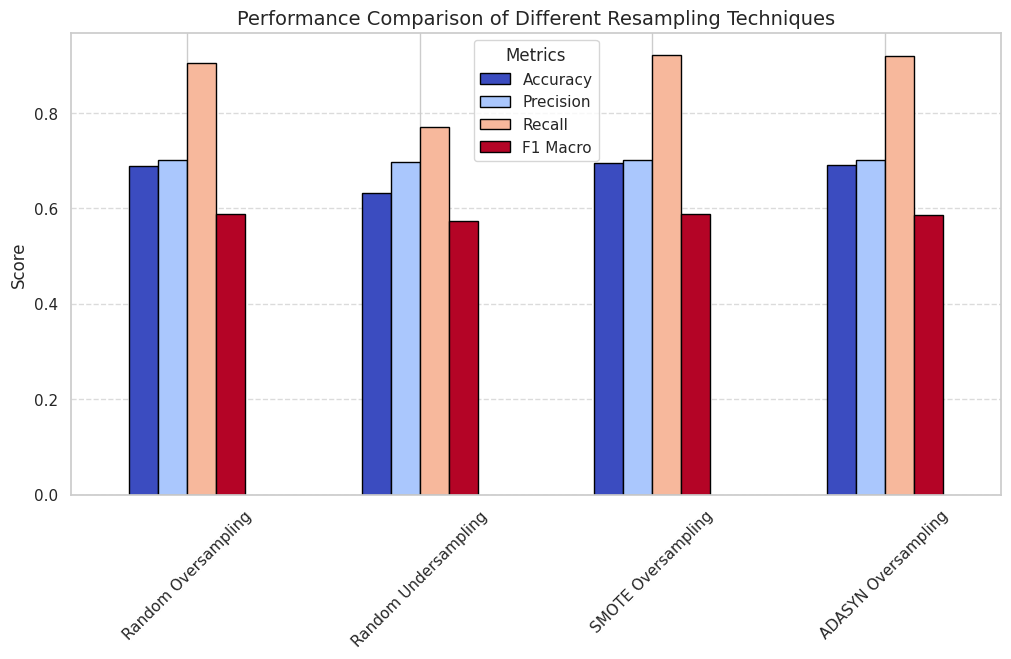

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define different resampling techniques
resampling_methods = {
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "SMOTE Oversampling": SMOTE(random_state=42),
    "ADASYN Oversampling": ADASYN(random_state=42)
}

# Store results
results = {}

# Define classifiers
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                    n_estimators=500, max_depth=10, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)

lgbm = LGBMClassifier(random_state=42, n_estimators=500, max_depth=10, learning_rate=0.01,
                      subsample=0.8, colsample_bytree=0.8)

catboost = CatBoostClassifier(verbose=0, random_state=42, iterations=500, depth=10, learning_rate=0.01)

# Loop through each resampling method
for method_name, sampler in resampling_methods.items():
    # Apply resampling
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    
    # Create Voting Classifier
    voting_clf = VotingClassifier(estimators=[
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('catboost', catboost)
    ], voting='hard')

    # Train model
    voting_clf.fit(X_resampled, y_resampled)
    
    # Predict on test set
    y_pred = voting_clf.predict(X_test)
    
    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    # Store results
    results[method_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Macro": f1_macro
    }

# Convert results to DataFrame for easy visualization
results_df = pd.DataFrame(results).T
print(results_df)

# Visualization
plt.figure(figsize=(12, 6))
results_df.plot(kind="bar", figsize=(12, 6), colormap="coolwarm", edgecolor="black")
plt.title("Performance Comparison of Different Resampling Techniques", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Metrics")
plt.show()


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Define a moderate complexity neural network model
def create_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Create and compile model
model = create_model()

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(X_train_resampled, y_train_resampled, 
                    validation_split=0.2, epochs=100, batch_size=256, 
                    callbacks=[early_stopping, lr_scheduler], verbose=1)

# Predict on test set
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f'Deep Learning Model Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Macro: {f1_macro:.4f}')


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5155 - loss: 0.8109 - val_accuracy: 4.7939e-04 - val_loss: 0.9300 - learning_rate: 0.0010
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5984 - loss: 0.6815 - val_accuracy: 0.0058 - val_loss: 0.9842 - learning_rate: 0.0010
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6235 - loss: 0.6636 - val_accuracy: 0.0774 - val_loss: 0.9510 - learning_rate: 0.0010
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6443 - loss: 0.6449 - val_accuracy: 0.1824 - val_loss: 0.9119 - learning_rate: 0.0010
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6553 - loss: 0.6350 - val_accuracy: 0.3097 - val_loss: 0.8595 - learning_rate: 0.0010
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6573 - loss: 0.6333 - val_accuracy: 0.4056 - val_loss: 0.8042 - learning_rate: 0.0010
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6695 - loss: 0.6204 - val_accuracy: 

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
import numpy as np

# Define boosting models
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, probability=True)
lgbm = LGBMClassifier(random_state=42)
catboost = CatBoostClassifier(verbose=0, random_state=42)
gbm = GradientBoostingClassifier(random_state=42)
hist_gbm = HistGradientBoostingClassifier(random_state=42)

# K-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nn_oof_preds = np.zeros(len(y))
voting_oof_preds = np.zeros(len(y))

for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Handle class imbalance using SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    # Train boosting models
    xgb.fit(X_train_resampled, y_train_resampled)
    lgbm.fit(X_train_resampled, y_train_resampled)
    catboost.fit(X_train_resampled, y_train_resampled)
    gbm.fit(X_train_resampled, y_train_resampled)
    hist_gbm.fit(X_train_resampled, y_train_resampled)
    
    # Get soft predictions from boosting models
    xgb_pred = xgb.predict_proba(X_train_resampled)[:, 1]
    lgbm_pred = lgbm.predict_proba(X_train_resampled)[:, 1]
    catboost_pred = catboost.predict_proba(X_train_resampled)[:, 1]
    gbm_pred = gbm.predict_proba(X_train_resampled)[:, 1]
    hist_gbm_pred = hist_gbm.predict_proba(X_train_resampled)[:, 1]
    
    # Concatenate soft predictions with original features for NN training
    X_train_nn = np.column_stack((X_train_resampled, xgb_pred, lgbm_pred, catboost_pred, gbm_pred, hist_gbm_pred))
    X_val_nn = np.column_stack((X_val, xgb.predict_proba(X_val)[:, 1], lgbm.predict_proba(X_val)[:, 1],
                                catboost.predict_proba(X_val)[:, 1], gbm.predict_proba(X_val)[:, 1],
                                hist_gbm.predict_proba(X_val)[:, 1]))
    
    # Define a moderate complexity neural network model
    def create_model():
        model = Sequential([
            Dense(256, activation='relu', input_shape=(X_train_nn.shape[1],)),
            BatchNormalization(),
            Dropout(0.2),
            
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.1),
            
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.1),
            
            Dense(1, activation='sigmoid')
        ])
        
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
        return model
    
    # Create and compile model
    nn_model = create_model()
    
    # Define callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    
    # Train the neural network model
    nn_model.fit(X_train_nn, y_train_resampled, 
                 validation_data=(X_val_nn, y_val), epochs=100, batch_size=32, 
                 callbacks=[early_stopping, lr_scheduler], verbose=1)
    
    # Predict using neural network
    nn_oof_preds[val_idx] = nn_model.predict(X_val_nn).flatten()
    
    # Ensemble with earlier boosting models
    voting_clf = VotingClassifier(estimators=[('xgb', xgb), ('lgbm', lgbm), ('catboost', catboost)], voting='soft')
    voting_clf.fit(X_train_resampled, y_train_resampled)
    voting_oof_preds[val_idx] = voting_clf.predict_proba(X_val)[:, 1]

# Final prediction using average of NN and boosting predictions
final_pred = np.round((nn_oof_preds + voting_oof_preds) / 2)

# Evaluate model
accuracy = accuracy_score(y, final_pred)
precision = precision_score(y, final_pred, average='macro')
recall = recall_score(y, final_pred, average='macro')
f1_macro = f1_score(y, final_pred, average='macro')

print(f'Final Ensemble (NN + Boosting) Model Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Macro: {f1_macro:.4f}')


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [20:30:05] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "probability" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10429, number of negative: 10429
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3088
[LightGBM] [Info] Number of data points in the train set: 20858, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


652/652 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7968 - loss: 0.4323 - val_accuracy: 0.6175 - val_loss: 1.0814 - learning_rate: 0.0010
Epoch 2/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9073 - loss: 0.2204 - val_accuracy: 0.6225 - val_loss: 1.1813 - learning_rate: 0.0010
Epoch 3/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9209 - loss: 0.1931 - val_accuracy: 0.6090 - val_loss: 1.1676 - learning_rate: 0.0010
Epoch 4/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9201 - loss: 0.1942 - val_accuracy: 0.6217 - val_loss: 1.2403 - learning_rate: 0.0010
Epoch 5/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9295 - loss: 0.1713 - val_accuracy: 0.5903 - val_loss: 1.2290 - learning_rate: 0.0010
Epoch 6/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9314 - loss: 0.1670 - val_accuracy: 0.5845 - val_loss: 1.2681 - learning_rate: 0.0010
Epoch 7/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9361 - loss: 0.1558 - val_a

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [20:30:51] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "probability" } are not used.

  warnings.warn(smsg, UserWarning)


...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10430, number of negative: 10430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3088
[LightGBM] [Info] Number of data points in the train set: 20860, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


652/652 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8094 - loss: 0.3951 - val_accuracy: 0.6060 - val_loss: 1.1090 - learning_rate: 0.0010
Epoch 2/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9158 - loss: 0.2053 - val_accuracy: 0.6173 - val_loss: 1.1330 - learning_rate: 0.0010
Epoch 3/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9268 - loss: 0.1791 - val_accuracy: 0.5825 - val_loss: 1.1934 - learning_rate: 0.0010
Epoch 4/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9287 - loss: 0.1682 - val_accuracy: 0.5928 - val_loss: 1.1861 - learning_rate: 0.0010
Epoch 5/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9322 - loss: 0.1627 - val_accuracy: 0.6010 - val_loss: 1.2897 - learning_rate: 0.0010
Epoch 6/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9389 - loss: 0.1529 - val_accuracy: 0.6055 - val_loss: 1.2149 - learning_rate: 0.0010
Epoch 7/100
652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9450 - loss: 0.1398 - val_a

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [20:34:35] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "probability" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10430, number of negative: 10430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3088
[LightGBM] [Info] Number of data points in the train set: 20860, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Final Ensemble (NN + Boosting) Model Accuracy: 0.6302
Precision: 0.5744
Recall: 0.5631
F1 Macro: 0.5630
